<div style="background:#0b1220; padding:28px; border-radius:16px; color:#e5e7eb; font-family:Arial, sans-serif;">
  <h1 style="margin:0 0 10px 0;">🧠 Amazon Reviews: Topic Discovery & Topic Classification</h1>

  <p style="margin:0 0 14px 0; line-height:1.6; color:rgba(229,231,235,0.85);">
    Amazon hosts thousands of product reviews. In raw form, these texts are difficult to search and analyze at scale.
    This notebook aims to discover the main topics hidden in a ~1.6k review corpus and build a model that can assign
    a topic label to new reviews, enabling faster search and better content organization.
  </p>

  <div style="display:flex; gap:12px; flex-wrap:wrap;">
    <div style="background:rgba(255,255,255,0.05); border:1px solid rgba(255,255,255,0.1); padding:10px 12px; border-radius:12px; min-width:240px;">
      <div style="font-size:12px; opacity:0.8;">Problem</div>
      <div style="margin-top:4px;">Unstructured review text → hard to search</div>
    </div>
    <div style="background:rgba(255,255,255,0.05); border:1px solid rgba(255,255,255,0.1); padding:10px 12px; border-radius:12px; min-width:240px;">
      <div style="font-size:12px; opacity:0.8;">Goal</div>
      <div style="margin-top:4px;">Discover topics + auto-tag reviews</div>
    </div>
    <div style="background:rgba(255,255,255,0.05); border:1px solid rgba(255,255,255,0.1); padding:10px 12px; border-radius:12px; min-width:240px;">
      <div style="font-size:12px; opacity:0.8;">Outcome</div>
      <div style="margin-top:4px;">Topic clusters usable for search & filtering</div>
    </div>
  </div>
</div>

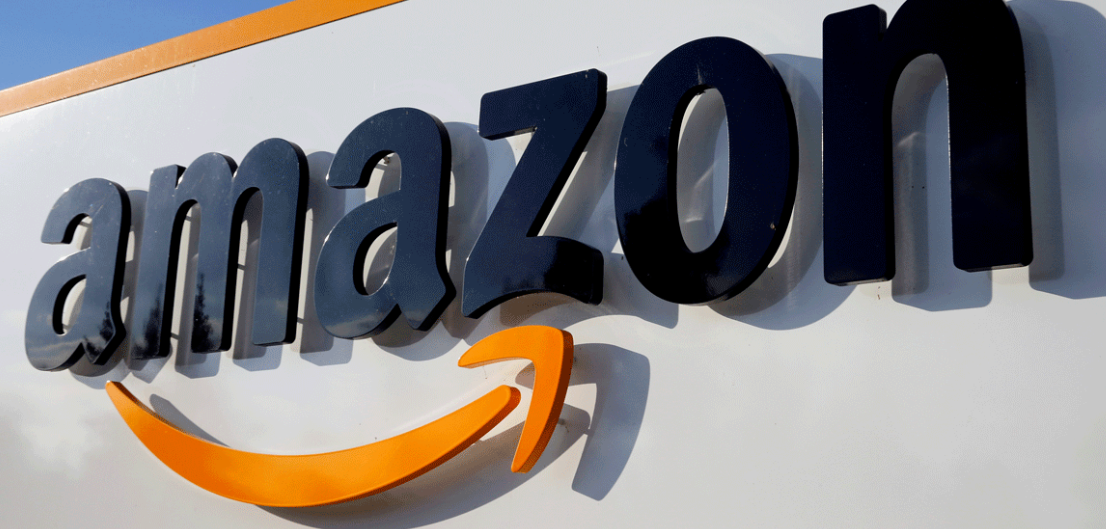

## 📦 Dataset Story

This dataset is a randomly sampled corpus of Amazon product ratings and reviews.
It contains nearly **1.6k customer reviews** across a selection of products.

**Why it matters**
- Reviews contain multiple themes such as quality, shipping, usability, pricing, durability, and customer support.
- Without topic labels, searching and grouping these reviews is slow and inconsistent.

**Objective**
1) Understand the dataset and apply the necessary cleanup  
2) Build a strong **Topic Modelling** approach to identify and classify review topics

## 🎯 Probability & Risk Matrix (Topic Modelling Lens)

- **High Probability / High Impact**
  - Topics will revolve around recurring product experience patterns (quality, shipping, price, usability).
  - Auto-tagging improves search and speeds up triage of feedback.

- **Medium Probability / High Impact**
  - Some reviews contain multiple topics (e.g., “great quality but late delivery”) → ambiguous labeling risk.
  - Short reviews (“Good”, “Nice”) provide weak topic signals.

- **Risks**
  - Small dataset size (~1.6k) can limit topic diversity.
  - Over-cleaning (aggressive stopwords/lemmatization) can remove topic-carrying words.
  - Choosing K (number of topics) incorrectly causes noisy clusters.

<div style="background:#0f172a; padding:22px; border-radius:16px; color:white; font-family:Arial, sans-serif;">
  <h2 style="margin:0 0 12px 0; text-align:center;">📑 Table of Contents</h2>

  <ol style="margin:0; padding-left:18px; line-height:1.9;">
    <li><a href="#setup" style="color:#93c5fd; text-decoration:none;">Setup & Libraries</a></li>
    <li><a href="#data-load" style="color:#93c5fd; text-decoration:none;">Reading the Dataset</a></li>
    <li><a href="#eda" style="color:#93c5fd; text-decoration:none;">EDA (Ratings & Review Length)</a></li>
    <li><a href="#clean" style="color:#93c5fd; text-decoration:none;">Text Cleaning Pipeline</a></li>
    <li><a href="#vector" style="color:#93c5fd; text-decoration:none;">Vectorization </a></li>
    <li><a href="#topic" style="color:#93c5fd; text-decoration:none;">Topic Modelling (NMF / LDA)</a></li>
    <li><a href="#label" style="color:#93c5fd; text-decoration:none;">Topic Labeling & Examples</a></li>
    <li><a href="#classify" style="color:#93c5fd; text-decoration:none;">Topic Classification Model</a></li>
    <li><a href="#insight" style="color:#93c5fd; text-decoration:none;">Insights for Search & Organization</a></li>
    <li><a href="#conclusion" style="color:#93c5fd; text-decoration:none;">Conclusion</a></li>
  </ol>
</div>

# 1️⃣ Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from langdetect import detect
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import warnings
warnings.filterwarnings('ignore')
from sklearn.feature_extraction.text import CountVectorizer

import re
import string
import nltk
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 2️⃣ Reading the Dataset

In [ ]:
df=pd.read_csv('7817_1.csv')

In [ ]:
df.head(5)

In [ ]:
df.shape

In [ ]:
df.columns

In [ ]:
df.info()

# 3️⃣ Exploratory Data Analysis (EDA)

In this section, we explore the dataset to better understand the structure, distribution, and characteristics of the reviews. 

The goal of this analysis is to identify patterns in ratings, review lengths, and commonly used words before applying text preprocessing and topic modelling techniques.

In [ ]:
df.isnull().sum()

In [ ]:
df = df[['reviews.text','reviews.title','reviews.rating']]

In [ ]:
df["text"] = df["reviews.title"] + " " + df["reviews.text"]

In [ ]:
df = df[['text','reviews.rating']]

In [ ]:
df.head()

In [ ]:
df = df.dropna()

In [ ]:
df.isnull().sum()

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x="reviews.rating", data=df)
plt.title("Rating Distribution")
plt.show()

In [ ]:
df["review_length"] = df["text"].apply(len)

plt.figure(figsize=(8,5))
sns.histplot(df["review_length"], bins=30)
plt.title("Review Length Distribution")
plt.show()

In [ ]:
df["word_count"] = df["text"].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
sns.histplot(df["word_count"], bins=30)
plt.title("Word Count Distribution")
plt.show()

# 4️⃣ Text Preprocessing

### 4.1 Lowercase Conversion

In [ ]:
df["text"] = df["text"].str.lower()

### 4.2 Removing Punctuation

In [ ]:
df['text']=df['text'].str.replace('[^\w\s]','',regex=True) 

### 4.3 Removing Numbers

In [ ]:
df["text"] = df["text"].str.replace(r"\d+", "", regex=True)

### 4.4. Removes newline characters (line breaks)

In [ ]:
df['text']=df['text'].str.replace('\n','' ,regex=True)

### 4.5 Removes carriage return characters

In [ ]:
df['text']=df['text'].str.replace('\r','' ,regex=True)

### 4.6 Tokenization

In [ ]:
from nltk.tokenize import word_tokenize

df['tokens'] = df['text'].apply(word_tokenize)

df[['text','tokens']].head()


### 4.7 Stopwords Removal (English)

In [ ]:
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words("english"))

df["tokens"] = df["tokens"].apply(lambda x: [w for w in x if w not in stop_words])

df[["text","tokens"]].head()

In [ ]:
df["tokens"] = df["tokens"].apply(lambda x: [w for w in x if w.isalpha() and len(w) > 2])

### 4.8 Stemming

Stemming reduces words to their root form by removing suffixes. 
However, the resulting word may not always be a valid dictionary word.

In [ ]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

df["tokens"] = df["tokens"].apply(lambda x: [stemmer.stem(word) for word in x])

df[["text","tokens"]].head()

### 4.9 Lemmatization

Lemmatization converts words into their base or dictionary form using linguistic rules.
This process preserves meaningful words and improves topic modeling quality.

In [ ]:
from nltk.stem import WordNetLemmatizer
import nltk

nltk.download("wordnet")

lemmatizer = WordNetLemmatizer()

df["tokens"] = df["tokens"].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])

df[["text","tokens"]].head()

In [ ]:
df["clean_text"] = df["tokens"].apply(lambda x: " ".join(x))

In [ ]:
df["clean_text"].head()

# 5️⃣ Vectorization

In [ ]:
vect = CountVectorizer(ngram_range=(1,2))

x = vect.fit_transform(df["clean_text"])

tf = pd.DataFrame(
    x.toarray(),
    columns=vect.get_feature_names_out()
)

In [ ]:
import numpy as np

word_counts = np.asarray(x.sum(axis=0)).ravel()
words = vect.get_feature_names_out()

top_idx = np.argsort(word_counts)[::-1][:20]

top_words = pd.DataFrame({
    "word": words[top_idx],
    "count": word_counts[top_idx]
})

top_words

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(top_words["word"], top_words["count"])
plt.title("Top 20 Most Frequent Words")
plt.gca().invert_yaxis()
plt.show()

# 6️⃣ Topic Modeling

### 6.1 NMF (TF-IDF ile)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
import numpy as np
import pandas as pd

n_topics = 5

tfidf = TfidfVectorizer(
    max_features=8000,
    min_df=3,
    max_df=0.9,
    ngram_range=(1,2)
)

x_tfidf = tfidf.fit_transform(df["clean_text"])

nmf = NMF(n_components=n_topics, random_state=42)
W = nmf.fit_transform(x_tfidf)   # doc-topic
H = nmf.components_              # topic-term

In [ ]:
terms = np.array(tfidf.get_feature_names_out())

def show_topics(model_components, terms, n_top_words=10):
    for topic_idx, topic in enumerate(model_components):
        top_ids = np.argsort(topic)[::-1][:n_top_words]
        print(f"Topic {topic_idx+1}: " + ", ".join(terms[top_ids]))

show_topics(H, terms, n_top_words=12)

### 6.2 LDA (CountVectorizer ile)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

cv = CountVectorizer(
    max_features=8000,
    min_df=3,
    max_df=0.9,
    ngram_range=(1,2)
)

x_counts = cv.fit_transform(df["clean_text"])

lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    learning_method="batch"
)

lda.fit(x_counts)

In [ ]:
terms_lda = np.array(cv.get_feature_names_out())

show_topics(lda.components_, terms_lda, n_top_words=12)

### NMF ile topic label (doc -> topic)

In [ ]:
df["topic_nmf"] = W.argmax(axis=1)
df[["clean_text","topic_nmf"]].head()

### LDA ile topic label (doc -> topic)

In [ ]:
doc_topic = lda.transform(x_counts)
df["topic_lda"] = doc_topic.argmax(axis=1)
df[["clean_text","topic_lda"]].head()

In [ ]:
df["topic_nmf"].value_counts()

In [ ]:
df["topic_lda"].value_counts()

# 7️⃣ Topic Labeling & Interpretation

In [ ]:
topic_labels = {
0: "Smart Speaker & Audio",
1: "General User Feedback",
2: "Headphones & Earbuds",
3: "Tablet / Kindle Devices",
4: "Headphone Performance"
}

df["topic_name"] = df["topic_nmf"].map(topic_labels)

df[["clean_text","topic_nmf","topic_name"]].head()

In [ ]:
for topic in range(5):
    print("\n")
    print("TOPIC:", topic_labels[topic])
    print(df[df["topic_nmf"] == topic]["clean_text"].head(3))

In [ ]:

df["topic_name"].value_counts().plot(
    kind="bar",
    figsize=(8,5),
    title="Topic Distribution"
)

plt.show()

# 8️⃣ Topic Classification Model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

x = df["clean_text"]
y = df["topic_nmf"]   # hedef: topic id

x_train, x_test, y_train, y_test = train_test_split(
   x ,y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
x_train_vec = tfidf.fit_transform(x_train)
x_test_vec  = tfidf.transform(x_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = LogisticRegression(max_iter=200)
model.fit(x_train_vec, y_train)

y_pred = model.predict(x_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

The topic classification model achieved a high accuracy of **97.88%** using Logistic Regression with TF-IDF features.

Most topics were classified with very high precision and recall values.  
Topic 0 and Topic 3, which represent the majority of reviews, were predicted with near-perfect performance.

Minor performance drops were observed in Topic 4 due to the smaller number of samples, which is a common issue in imbalanced datasets.

Overall, the model demonstrates strong capability in automatically assigning reviews to their corresponding topics.

# 9️⃣ Insights for Search & Organization

The topic modeling analysis revealed that customer reviews mainly focus on a few dominant product themes.

The most discussed topics are **Smart Speakers & Audio devices** and **Tablet / Kindle devices**, indicating that these product categories generate the highest user engagement.

Smaller clusters such as **Headphones & Earbuds** and **Headphone Performance** highlight more specific product feedback.

These insights can help Amazon:
- organize reviews into structured categories,
- improve product search filtering,
- quickly identify product-specific feedback,
- prioritize improvements based on customer discussions.

# 🔟 Conclusion

This project analyzed Amazon product reviews using Natural Language Processing techniques.

After cleaning and preprocessing the review texts, vectorization methods were applied to convert textual data into numerical features. Topic modeling techniques such as NMF and LDA were then used to uncover the main themes discussed in the reviews.

Finally, a Logistic Regression model was trained to automatically classify reviews into their corresponding topics with an accuracy of **97.88%**.

The results demonstrate that NLP-based topic analysis can effectively structure large volumes of customer feedback and provide actionable insights for product improvement and customer experience management.

In [ ]:
import joblib

joblib.dump(model, "topic_classifier_model.pkl")

In [ ]:
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

In [ ]:
joblib.dump(topic_labels, "topic_labels.pkl")